In [1]:
import pandas as pd
import numpy as np

# Morosidad

In [2]:
import pandas as pd

path = "data/"

df_moro = pd.read_csv(
    path + "morosidad_bde.csv",
    header=None,
    encoding="latin-1"
)

df_moro.columns = ["fecha_raw", "morosidad"]

df_moro = df_moro[df_moro["fecha_raw"].str.match(r"^[a-z]{3}\d{2}$", na=False)]

df_moro["morosidad"] = pd.to_numeric(df_moro["morosidad"], errors="coerce")

meses = {
    "ene": "01", "feb": "02", "mar": "03", "abr": "04",
    "may": "05", "jun": "06", "jul": "07", "ago": "08",
    "sep": "09", "oct": "10", "nov": "11", "dic": "12"
}

df_moro["mes"] = df_moro["fecha_raw"].str[:3].map(meses)
df_moro["anio"] = "20" + df_moro["fecha_raw"].str[-2:]

df_moro["fecha"] = pd.to_datetime(df_moro["anio"] + "-" + df_moro["mes"] + "-01")

df_moro = df_moro[["fecha", "morosidad"]]
df_moro = df_moro.sort_values("fecha").reset_index(drop=True)

In [3]:
df_moro.info()
df_moro.head()
df_moro.tail()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 288 entries, 0 to 287
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   fecha      288 non-null    datetime64[ns]
 1   morosidad  288 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 4.6 KB


,fecha,morosidad
283,2025-08-01,2.93
284,2025-09-01,2.87
285,2025-10-01,2.84
286,2025-11-01,2.78
287,2025-12-01,2.71


<Axes: xlabel='fecha'>

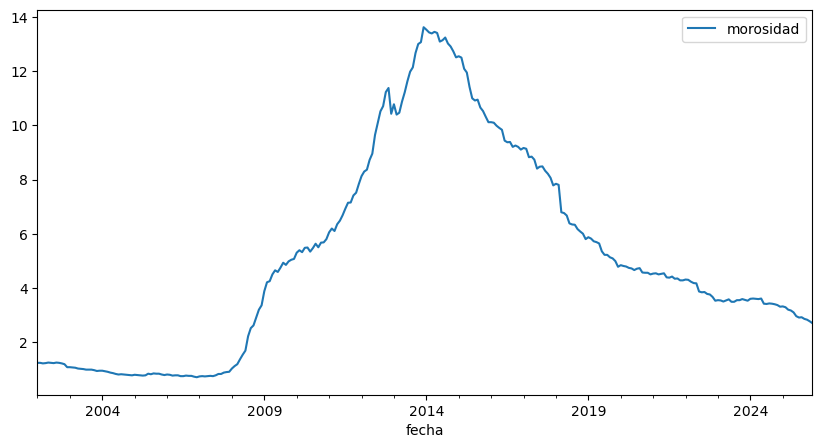

In [4]:
df_moro.plot(x="fecha", y="morosidad", figsize=(10,5))

# Euribor

In [5]:
df_eur = pd.read_csv(
    path + "euribor_bde.csv",
    header=None,
    encoding="latin-1"
)

In [6]:
df_eur.head(20)
df_eur.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8854 entries, 0 to 8853
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       8854 non-null   object
 1   1       8854 non-null   object
dtypes: object(2)
memory usage: 138.5+ KB


In [7]:
import pandas as pd
import numpy as np

# Ruta
path = "data/"

# Leer archivo
df_eur = pd.read_csv(
    path + "euribor_bde.csv",
    header=None,
    encoding="latin-1"
)

# Renombrar columnas
df_eur.columns = ["fecha_raw", "euribor_raw"]

# Filtrar solo filas con fecha diaria tipo 02ene02, 15mar10, etc.
df_eur = df_eur[df_eur["fecha_raw"].str.match(r"^\d{2}[a-z]{3}\d{2}$", na=False)].copy()

# Reemplazar guiones por NaN
df_eur["euribor_raw"] = df_eur["euribor_raw"].replace("-", np.nan)

# Convertir a numérico
df_eur["euribor"] = pd.to_numeric(df_eur["euribor_raw"], errors="coerce")

# Diccionario de meses
meses = {
    "ene": "01", "feb": "02", "mar": "03", "abr": "04",
    "may": "05", "jun": "06", "jul": "07", "ago": "08",
    "sep": "09", "oct": "10", "nov": "11", "dic": "12"
}

# Extraer partes de la fecha
df_eur["dia"] = df_eur["fecha_raw"].str[:2]
df_eur["mes_txt"] = df_eur["fecha_raw"].str[2:5]
df_eur["anio"] = "20" + df_eur["fecha_raw"].str[5:7]

# Convertir mes texto a número
df_eur["mes"] = df_eur["mes_txt"].map(meses)

# Crear fecha diaria
df_eur["fecha"] = pd.to_datetime(
    df_eur["anio"] + "-" + df_eur["mes"] + "-" + df_eur["dia"],
    errors="coerce"
)

# Quedarnos con columnas útiles
df_eur = df_eur[["fecha", "euribor"]].copy()

# Crear fecha mensual (inicio de mes)
df_eur["fecha"] = df_eur["fecha"].dt.to_period("M").dt.to_timestamp()

# Agregar a mensual usando media
df_eur = (
    df_eur.groupby("fecha", as_index=False)["euribor"]
    .mean()
    .sort_values("fecha")
    .reset_index(drop=True)
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 291 entries, 0 to 290
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   fecha    291 non-null    datetime64[ns]
 1   euribor  291 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 4.7 KB


<Axes: xlabel='fecha'>

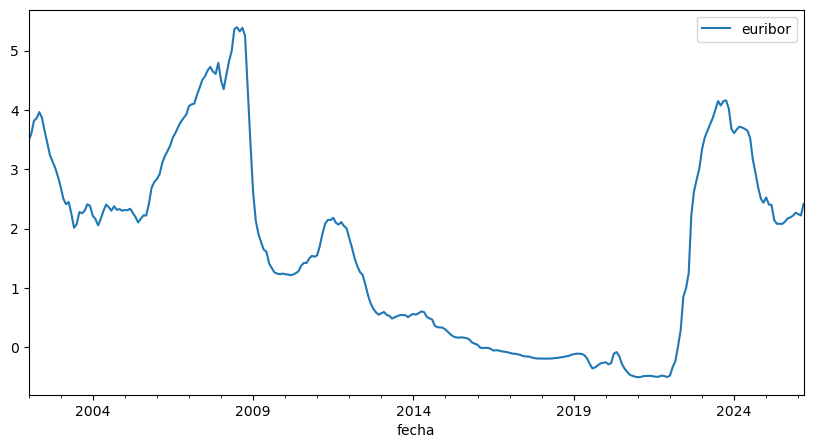

In [8]:
df_eur.info()
df_eur.head()
df_eur.tail()
df_eur.plot(x="fecha", y="euribor", figsize=(10, 5))

# IPC

In [9]:
import pandas as pd

# Leer archivo del IPC
df_ipc = pd.read_csv(
    path + "ipc_ine.csv",
    sep=";",
    encoding="latin-1"
)

# Ver columnas reales
print(df_ipc.columns)

# Renombrar columnas
df_ipc.columns = ["grupo", "tipo", "periodo", "ipc"]

# Filtrar índice general
df_ipc = df_ipc[df_ipc["grupo"].str.contains("general", case=False, na=False)].copy()

# Convertir IPC a numérico
df_ipc["ipc"] = df_ipc["ipc"].str.replace(",", ".", regex=False)
df_ipc["ipc"] = pd.to_numeric(df_ipc["ipc"], errors="coerce")

# Convertir periodo a fecha mensual
df_ipc["anio"] = df_ipc["periodo"].str[:4]
df_ipc["mes"] = df_ipc["periodo"].str[-2:]
df_ipc["fecha"] = pd.to_datetime(df_ipc["anio"] + "-" + df_ipc["mes"] + "-01")

# Ordenar de más antiguo a más reciente
df_ipc = df_ipc.sort_values("fecha").reset_index(drop=True)

# Calcular inflación interanual
df_ipc["inflacion_interanual"] = df_ipc["ipc"].pct_change(12) * 100

# Dataset final
df_ipc = df_ipc[["fecha", "ipc", "inflacion_interanual"]]

Index(['Grupos ECOICOP ver.2', 'Tipo de dato', 'Periodo', 'Total'], dtype='object')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290 entries, 0 to 289
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   fecha                 290 non-null    datetime64[ns]
 1   ipc                   290 non-null    float64       
 2   inflacion_interanual  278 non-null    float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 6.9 KB


<Axes: xlabel='fecha'>

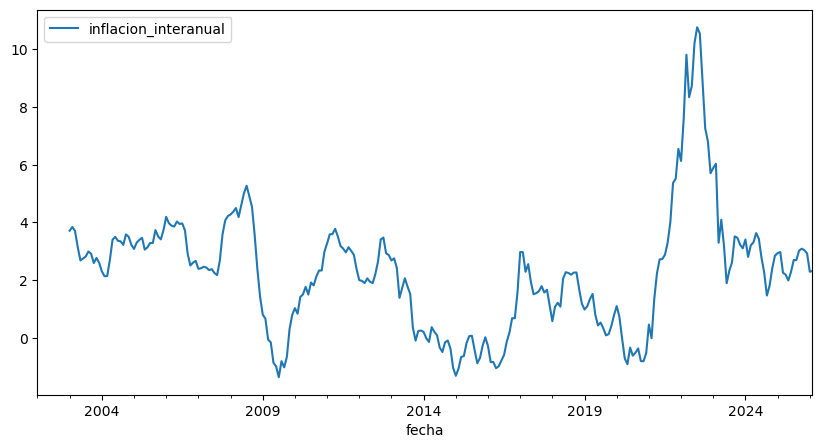

In [10]:
df_ipc.info()
df_ipc.head()
df_ipc.tail()
df_ipc.plot(x="fecha", y="inflacion_interanual", figsize=(10,5))

# Paro

In [11]:
import pandas as pd

# Leer archivo
df_paro = pd.read_csv(
    path + "paro_ine.csv",
    sep=";",
    encoding="latin-1"
)

# Ver columnas
print(df_paro.columns)

# Renombrar columnas (ajusta si cambia)
df_paro.columns = ["sexo", "region", "edad", "periodo", "paro"]

# Filtrar datos nacionales totales
df_paro = df_paro[
    (df_paro["sexo"].str.contains("Ambos", na=False)) &
    (df_paro["region"].str.contains("Total", na=False)) &
    (df_paro["edad"].str.contains("Total", na=False))
].copy()

# Convertir paro a numérico
df_paro["paro"] = df_paro["paro"].str.replace(",", ".", regex=False)
df_paro["paro"] = pd.to_numeric(df_paro["paro"], errors="coerce")

# Convertir periodo (2025T4 → fecha)
df_paro["anio"] = df_paro["periodo"].str[:4]
df_paro["trimestre"] = df_paro["periodo"].str[-1]

# Mapear trimestre a mes inicial
map_trimestre = {
    "1": "01",
    "2": "04",
    "3": "07",
    "4": "10"
}

df_paro["mes"] = df_paro["trimestre"].map(map_trimestre)

df_paro["fecha"] = pd.to_datetime(df_paro["anio"] + "-" + df_paro["mes"] + "-01")

# Ordenar
df_paro = df_paro.sort_values("fecha").reset_index(drop=True)

# 🔴 PASO CLAVE: pasar de trimestral a mensual
df_paro = df_paro.set_index("fecha").resample("MS").ffill().reset_index()

# Dataset final
df_paro = df_paro[["fecha", "paro"]]

Index(['Sexo', 'Comunidades y Ciudades Autónomas', 'Edad', 'Periodo', 'Total'], dtype='object')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   fecha   286 non-null    datetime64[ns]
 1   paro    286 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 4.6 KB


<Axes: xlabel='fecha'>

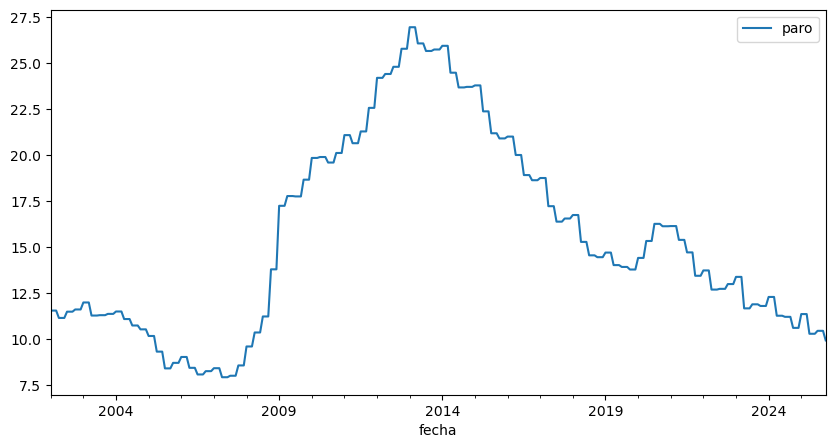

In [12]:
df_paro.info()
df_paro.head()
df_paro.tail()

df_paro.plot(x="fecha", y="paro", figsize=(10,5))

# Merge

In [13]:
# Merge progresivo

df_final = df_moro.merge(df_eur, on="fecha", how="inner")
df_final = df_final.merge(df_ipc, on="fecha", how="inner")
df_final = df_final.merge(df_paro, on="fecha", how="inner")

# Ordenar
df_final = df_final.sort_values("fecha").reset_index(drop=True)

In [14]:
df_final.info()
df_final.head()
df_final.tail()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   fecha                 286 non-null    datetime64[ns]
 1   morosidad             286 non-null    float64       
 2   euribor               286 non-null    float64       
 3   ipc                   286 non-null    float64       
 4   inflacion_interanual  274 non-null    float64       
 5   paro                  286 non-null    float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 13.5 KB


,fecha,morosidad,euribor,ipc,inflacion_interanual,paro
281,2025-06-01,2.97,2.080905,100.382,2.285534,10.29
282,2025-07-01,2.92,2.079087,100.305,2.694706,10.45
283,2025-08-01,2.93,2.113905,100.345,2.693603,10.45
284,2025-09-01,2.87,2.171500,100.059,3.022971,10.45
285,2025-10-01,2.84,2.187304,100.748,3.089155,9.93


In [15]:
df_final.isnull().sum()

fecha                    0
morosidad                0
euribor                  0
ipc                      0
inflacion_interanual    12
paro                     0
dtype: int64

<Axes: xlabel='fecha'>

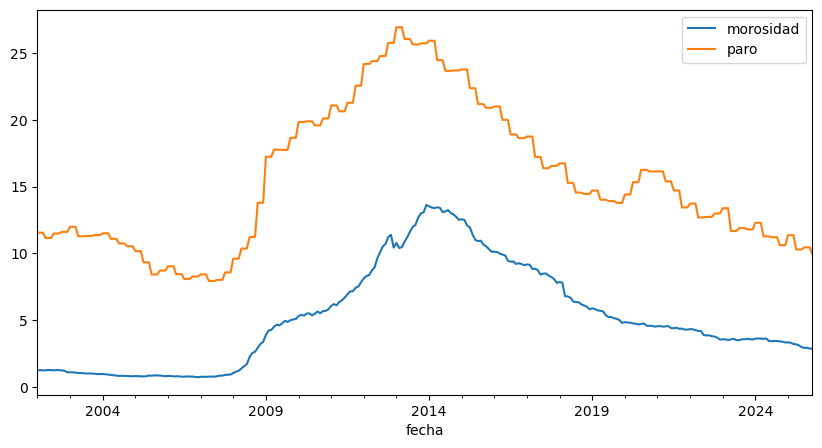

In [16]:
df_final.plot(x="fecha", y=["morosidad", "paro"], figsize=(10,5))

In [17]:
df_final.to_csv("data/df_final.csv", index=False)

# Análisis

In [18]:
df_final.describe()

,fecha,morosidad,euribor,ipc,inflacion_interanual,paro
count,286,286.000000,286.000000,286.000000,274.000000,286.000000
mean,2013-11-15 12:25:10.489510400,5.173497,1.641275,77.953605,2.259324,15.505909
min,2002-01-01 00:00:00,0.720000,-0.504700,58.717000,-1.368223,7.930000
25%,2007-12-08 18:00:00,1.250000,-0.011726,71.561500,0.745416,11.270000
50%,2013-11-16 00:00:00,4.520000,1.533272,78.825000,2.329224,14.410000
75%,2019-10-24 06:00:00,7.847500,2.763601,82.026750,3.299176,19.877500
max,2025-10-01 00:00:00,13.620000,5.393217,100.748000,10.770423,26.940000
std,NaN,3.763103,1.634998,10.288048,2.106035,5.365358


In [19]:
df_final.corr()

,fecha,morosidad,euribor,ipc,inflacion_interanual,paro
fecha,1.000000,0.330869,-0.408012,0.962897,0.005744,0.140370
morosidad,0.330869,1.000000,-0.647738,0.289723,-0.488315,0.920967
euribor,-0.408012,-0.647738,1.000000,-0.221853,0.411006,-0.583861
ipc,0.962897,0.289723,-0.221853,1.000000,0.117930,0.119357
inflacion_interanual,0.005744,-0.488315,0.411006,0.117930,1.000000,-0.455793
paro,0.140370,0.920967,-0.583861,0.119357,-0.455793,1.000000


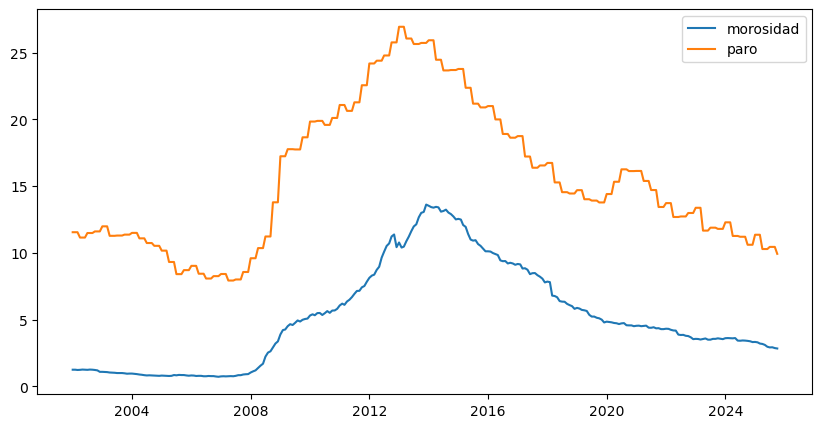

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df_final["fecha"], df_final["morosidad"], label="morosidad")
plt.plot(df_final["fecha"], df_final["paro"], label="paro")
plt.legend()
plt.show()

In [21]:
df_final["paro_lag_6"] = df_final["paro"].shift(6)
df_final["paro_lag_12"] = df_final["paro"].shift(12)

df_final["euribor_lag_6"] = df_final["euribor"].shift(6)
df_final["euribor_lag_12"] = df_final["euribor"].shift(12)

In [22]:
df_final[[
    "morosidad",
    "paro",
    "paro_lag_6",
    "paro_lag_12",
    "euribor",
    "euribor_lag_6"
]].corr()

,morosidad,paro,paro_lag_6,paro_lag_12,euribor,euribor_lag_6
morosidad,1.000000,0.920967,0.953812,0.957115,-0.647738,-0.570710
paro,0.920967,1.000000,0.966555,0.908782,-0.583861,-0.472448
paro_lag_6,0.953812,0.966555,1.000000,0.966071,-0.646083,-0.584233
paro_lag_12,0.957115,0.908782,0.966071,1.000000,-0.670709,-0.646108
euribor,-0.647738,-0.583861,-0.646083,-0.670709,1.000000,0.901654
euribor_lag_6,-0.570710,-0.472448,-0.584233,-0.646108,0.901654,1.000000


In [23]:
df_final.drop(columns="fecha").corr()

,morosidad,euribor,ipc,inflacion_interanual,paro,paro_lag_6,paro_lag_12,euribor_lag_6,euribor_lag_12
morosidad,1.000000,-0.647738,0.289723,-0.488315,0.920967,0.953812,0.957115,-0.570710,-0.484661
euribor,-0.647738,1.000000,-0.221853,0.411006,-0.583861,-0.646083,-0.670709,0.901654,0.732370
ipc,0.289723,-0.221853,1.000000,0.117930,0.119357,0.142519,0.162979,-0.240656,-0.273799
inflacion_interanual,-0.488315,0.411006,0.117930,1.000000,-0.455793,-0.442266,-0.394304,0.190773,0.068121
paro,0.920967,-0.583861,0.119357,-0.455793,1.000000,0.966555,0.908782,-0.472448,-0.354264
paro_lag_6,0.953812,-0.646083,0.142519,-0.442266,0.966555,1.000000,0.966071,-0.584233,-0.468548
paro_lag_12,0.957115,-0.670709,0.162979,-0.394304,0.908782,0.966071,1.000000,-0.646108,-0.581693
euribor_lag_6,-0.570710,0.901654,-0.240656,0.190773,-0.472448,-0.584233,-0.646108,1.000000,0.901638
euribor_lag_12,-0.484661,0.732370,-0.273799,0.068121,-0.354264,-0.468548,-0.581693,0.901638,1.000000


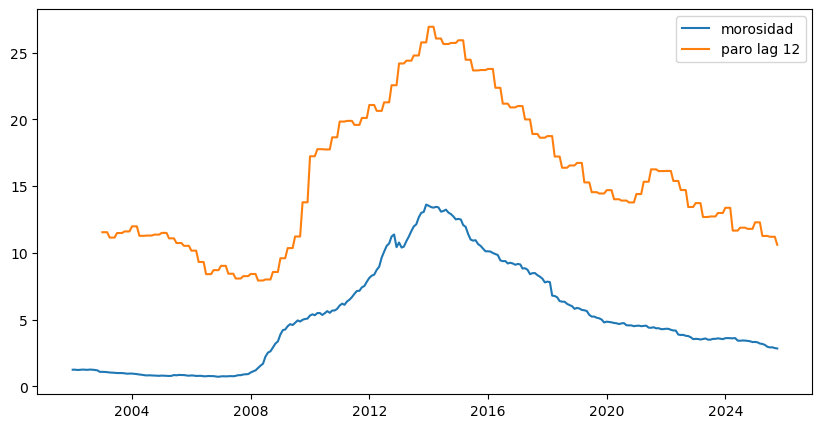

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df_final["fecha"], df_final["morosidad"], label="morosidad")
plt.plot(df_final["fecha"], df_final["paro_lag_12"], label="paro lag 12")
plt.legend()
plt.show()

# Alerta

In [25]:
df_alert_final = df_final.copy()

df_alert_final["paro_lag_12"] = df_alert_final["paro"].shift(12)

# tendencia real
df_alert_final["paro_change_6m"] = df_alert_final["paro_lag_12"] - df_alert_final["paro_lag_12"].shift(6)

In [26]:
def nivel_riesgo(paro_change):
    if paro_change < 0:
        return "bajo"
    elif paro_change < 1:
        return "medio"
    else:
        return "alto"

df_alert_final["nivel_riesgo"] = df_alert_final["paro_change_6m"].apply(nivel_riesgo)

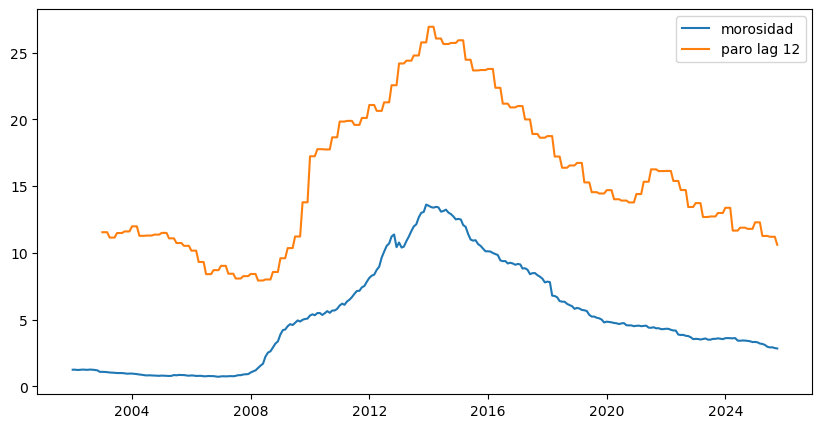

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df_alert_final["fecha"], df_alert_final["morosidad"], label="morosidad")
plt.plot(df_alert_final["fecha"], df_alert_final["paro_lag_12"], label="paro lag 12")
plt.legend()
plt.show()

# Modelo

In [28]:
import pandas as pd
import statsmodels.api as sm

df = pd.read_csv("data/df_final.csv")
df["fecha"] = pd.to_datetime(df["fecha"])

# Variables derivadas mínimas y útiles
df["paro_lag_12"] = df["paro"].shift(12)
df["delta_paro_6m"] = df["paro"] - df["paro"].shift(6)

# Dataset de modelado
df_model = df[["morosidad", "paro_lag_12", "euribor", "inflacion_interanual", "delta_paro_6m"]].dropna()

# Modelo 1
X1 = sm.add_constant(df_model[["paro_lag_12"]])
y = df_model["morosidad"]
model1 = sm.OLS(y, X1).fit()
print(model1.summary())

# Modelo 2
X2 = sm.add_constant(df_model[["paro_lag_12", "euribor", "inflacion_interanual"]])
model2 = sm.OLS(y, X2).fit()
print(model2.summary())

# Modelo 3
X3 = sm.add_constant(df_model[["paro_lag_12", "delta_paro_6m", "euribor"]])
model3 = sm.OLS(y, X3).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:              morosidad   R-squared:                       0.916
Model:                            OLS   Adj. R-squared:                  0.916
Method:                 Least Squares   F-statistic:                     2969.
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          2.27e-148
Time:                        10:04:54   Log-Likelihood:                -411.06
No. Observations:                 274   AIC:                             826.1
Df Residuals:                     272   BIC:                             833.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -5.1429      0.203    -25.281      

# Predicción

In [29]:
df_model = df[["fecha", "morosidad", "paro_lag_12", "euribor", "inflacion_interanual", "delta_paro_6m"]].dropna()

In [30]:
df_model["pred_morosidad"] = model1.predict(X1)

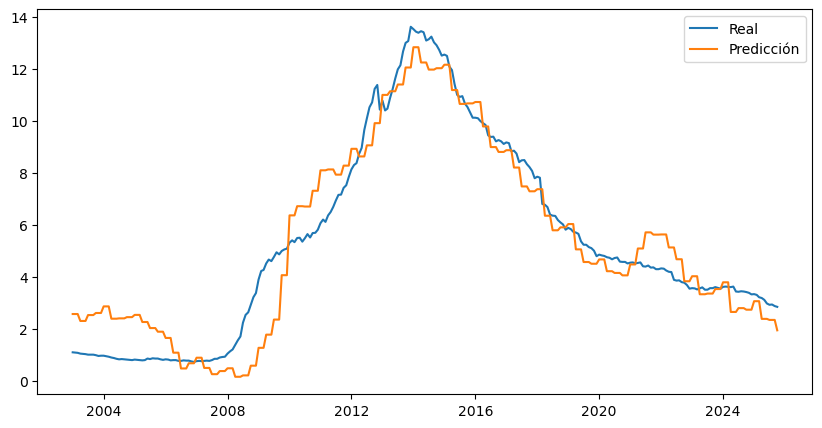

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df_model["fecha"], df_model["morosidad"], label="Real")
plt.plot(df_model["fecha"], df_model["pred_morosidad"], label="Predicción")
plt.legend()
plt.show()

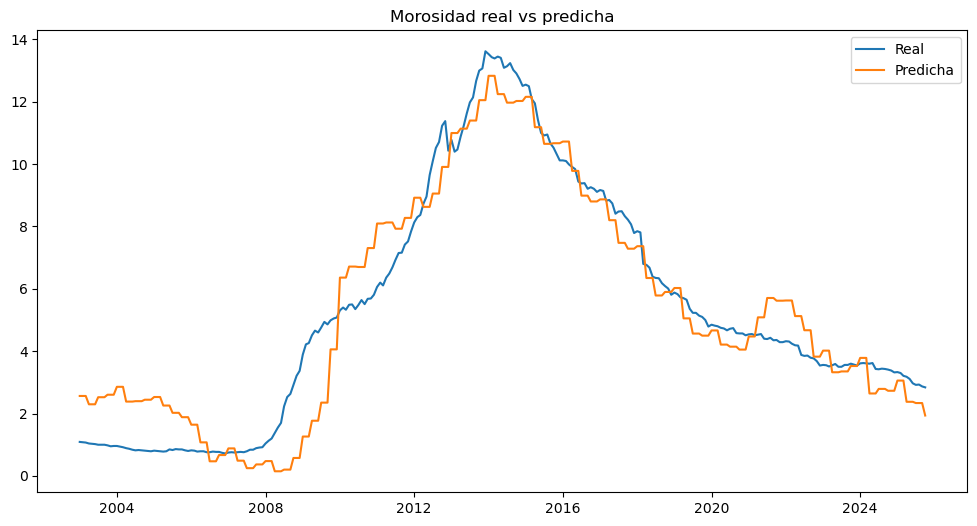

In [32]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

df = pd.read_csv("data/df_final.csv")
df["fecha"] = pd.to_datetime(df["fecha"])

df["paro_lag_12"] = df["paro"].shift(12)
df["delta_paro_6m"] = df["paro"] - df["paro"].shift(6)

df_model = df[[
    "fecha",
    "morosidad",
    "paro_lag_12",
    "euribor",
    "inflacion_interanual",
    "delta_paro_6m"
]].dropna()

X1 = sm.add_constant(df_model[["paro_lag_12"]])
y = df_model["morosidad"]

model1 = sm.OLS(y, X1).fit()
df_model["pred_morosidad"] = model1.predict(X1)

plt.figure(figsize=(12,6))
plt.plot(df_model["fecha"], df_model["morosidad"], label="Real")
plt.plot(df_model["fecha"], df_model["pred_morosidad"], label="Predicha")
plt.legend()
plt.title("Morosidad real vs predicha")
plt.show()

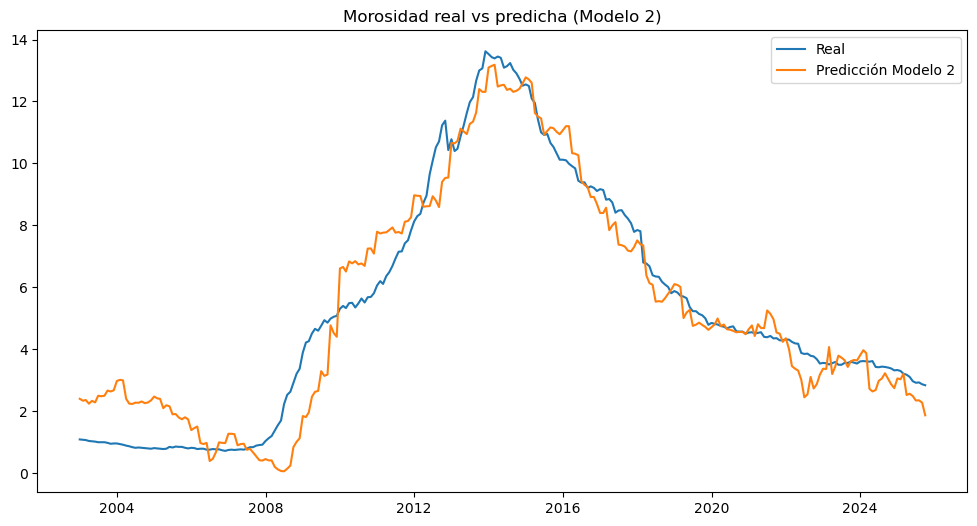

In [33]:
X2 = sm.add_constant(df_model[["paro_lag_12", "euribor", "inflacion_interanual"]])
df_model["pred_morosidad_m2"] = model2.predict(X2)

plt.figure(figsize=(12,6))
plt.plot(df_model["fecha"], df_model["morosidad"], label="Real")
plt.plot(df_model["fecha"], df_model["pred_morosidad_m2"], label="Predicción Modelo 2")
plt.legend()
plt.title("Morosidad real vs predicha (Modelo 2)")
plt.show()

# dashboard

In [34]:
df_final.to_csv("data/df_final.csv", index=False)

In [35]:
import pandas as pd
import statsmodels.api as sm

df = pd.read_csv("data/df_final.csv")
df["fecha"] = pd.to_datetime(df["fecha"])

# Variables derivadas
df["paro_lag_12"] = df["paro"].shift(12)

# Dataset para modelado
df_model = df[[
    "fecha",
    "morosidad",
    "paro",
    "paro_lag_12",
    "euribor",
    "inflacion_interanual"
]].dropna().copy()

# Modelo 1
X1 = sm.add_constant(df_model[["paro_lag_12"]])
y = df_model["morosidad"]
model1 = sm.OLS(y, X1).fit()
df_model["pred_morosidad_m1"] = model1.predict(X1)

# Modelo 2
X2 = sm.add_constant(df_model[["paro_lag_12", "euribor", "inflacion_interanual"]])
model2 = sm.OLS(y, X2).fit()
df_model["pred_morosidad_m2"] = model2.predict(X2)

# Guardar para Power BI
df_model.to_csv("data/dashboard_banca.csv", index=False)

In [36]:
corr_resumen = pd.DataFrame({
    "Variable": ["Paro", "Paro lag 12", "Euríbor", "Inflación interanual"],
    "Correlación con morosidad": [0.920967, 0.957115, -0.647738, -0.488315]
})

corr_resumen.to_csv("data/correlaciones_resumen.csv", index=False)

In [37]:
modelos_resumen = pd.DataFrame({
    "Modelo": ["Modelo 1", "Modelo 2", "Modelo 3"],
    "Variables": [
        "paro_lag_12",
        "paro_lag_12 + euribor + inflacion",
        "paro_lag_12 + delta_paro_6m + euribor"
    ],
    "R2": [model1.rsquared, model2.rsquared, model3.rsquared],
    "R2_ajustado": [model1.rsquared_adj, model2.rsquared_adj, model3.rsquared_adj]
})

modelos_resumen.to_csv("data/modelos_resumen.csv", index=False)

In [38]:
escenarios = pd.DataFrame({
    "Escenario": ["Estable", "Deterioro moderado", "Estrés"],
    "Paro": [11, 13, 16]
})

escenarios["Morosidad estimada 12m"] = -5.1429 + 0.6673 * escenarios["Paro"]
escenarios.to_csv("data/escenarios_12m.csv", index=False)